## Import Library


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Preprocessing Data, clear data


In [ ]:
# Upload the file from your computer
from google.colab import files
uploaded = files.upload()

# # Read the file
df = pd.read_csv('medical.csv')
df.head()

Saving medical.csv to medical.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
needed_cols = ['sex', 'smoker', 'region']
for col in needed_cols:
    if col not in df.columns:
        raise ValueError(f"Row '{col}' does not exist in the dataset.")

df_processed = df.copy()
df_processed = pd.get_dummies(df_processed, columns=['sex', 'smoker', 'region'], drop_first=True)
df_processed['x0'] = 1
df_processed['HighCost'] = (df_processed['charges'] > df_processed['charges'].mean()).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


## Cost Reduction over Iteration


In [ ]:
# Prepare data for manual gradient descent
X = df_processed.drop(['charges', 'x0'], axis=1)
Y = df_processed['charges']

Y = np.array((Y - Y.mean()) / Y.std())
X = X.apply(lambda rec: (rec - rec.mean()) / rec.std(), axis=0)
X['x0'] = 1
X = X.values

In [ ]:
# Gradient descent functions
def initialize(dim):
    return np.random.rand(dim)

def predict_Y(theta, X):
    return np.dot(X, theta)

def get_cost(Y, Y_hat):
    Y_resd = Y - Y_hat
    return np.sum(np.dot(Y_resd.T, Y_resd)) / len(Y)

def update_theta(x, y, y_hat, theta_o, learning_rate):
    dw = (np.dot((y_hat - y), x) * 2) / len(y)
    return theta_o - learning_rate * dw

def run_gradient_descent(X, Y, alpha, num_interations):
    theta = initialize(X.shape[1])
    iter_num = 0
    gd_iterations_df = pd.DataFrame(columns=['iteration', 'cost'])
    result_idx = 0

    for each_iter in range(num_interations):
        Y_hat = predict_Y(theta, X)
        this_cost = get_cost(Y, Y_hat)
        prev_theta = theta
        theta = update_theta(X, Y, Y_hat, prev_theta, alpha)
        if iter_num % 10 == 0:
            gd_iterations_df.loc[result_idx] = [iter_num, this_cost]
            result_idx += 1
        iter_num += 1

    print("Final theta:", theta)
    return gd_iterations_df, theta

Final theta: [0.23590561 0.11401735 0.11327779 0.03138272 0.39718839 0.2179399
 0.20983656 0.19936105 0.49273934 0.02230132]


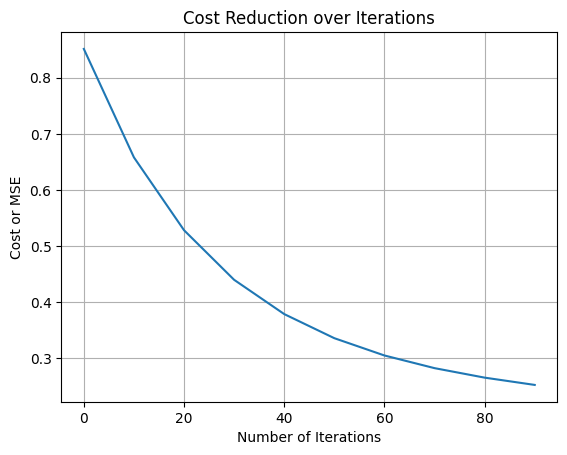

In [ ]:
# Run gradient descent
gd_iterations_df, final_theta = run_gradient_descent(X, Y, alpha=0.01, num_interations=100)

# Plot cost reduction
plt.plot(gd_iterations_df['iteration'], gd_iterations_df['cost'])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost or MSE")
plt.title("Cost Reduction over Iterations")
plt.grid(True)
plt.show()
# Predict using final theta and plot actual vs predicted charges
Y_pred = predict_Y(final_theta, X)
Y_actual = Y * df_processed['charges'].std() + df_processed['charges'].mean()
Y_pred_actual = Y_pred * df_processed['charges'].std() + df_processed['charges'].mean()

## Reality and Prediction

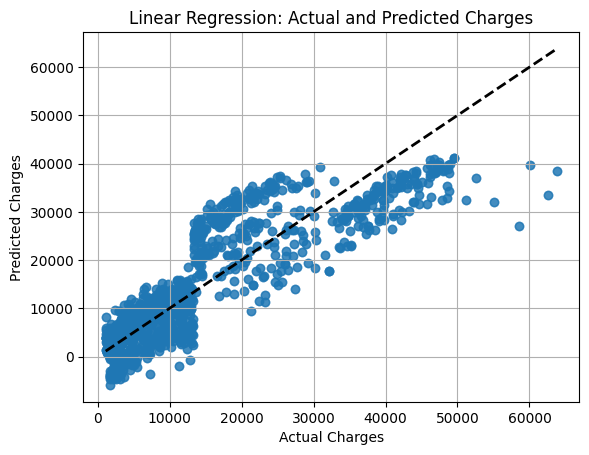

In [ ]:
# Predict using final theta and plot actual vs predicted charges
Y_pred = predict_Y(final_theta, X)
Y_actual = Y * df_processed['charges'].std() + df_processed['charges'].mean()
Y_pred_actual = Y_pred * df_processed['charges'].std() + df_processed['charges'].mean()

plt.scatter(Y_actual, Y_pred_actual, alpha=0.6)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Linear Regression: Actual and Predicted Charges')
plt.plot([Y_actual.min(), Y_actual.max()], [Y_actual.min(), Y_actual.max()], 'k--', lw=2)
plt.grid(True)
plt.show()

## Linear Regression Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluation Metrics for Regression
mse = mean_squared_error(Y_actual, Y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(Y_actual, Y_pred_actual)

print(f"Linear Regression Evaluation:")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  R² Score: {r2:.4f}")


Linear Regression Evaluation:
  Mean Squared Error (MSE): 35760038.36
  Root Mean Squared Error (RMSE): 5979.97
  R² Score: 0.7577


## Correlation heatmap

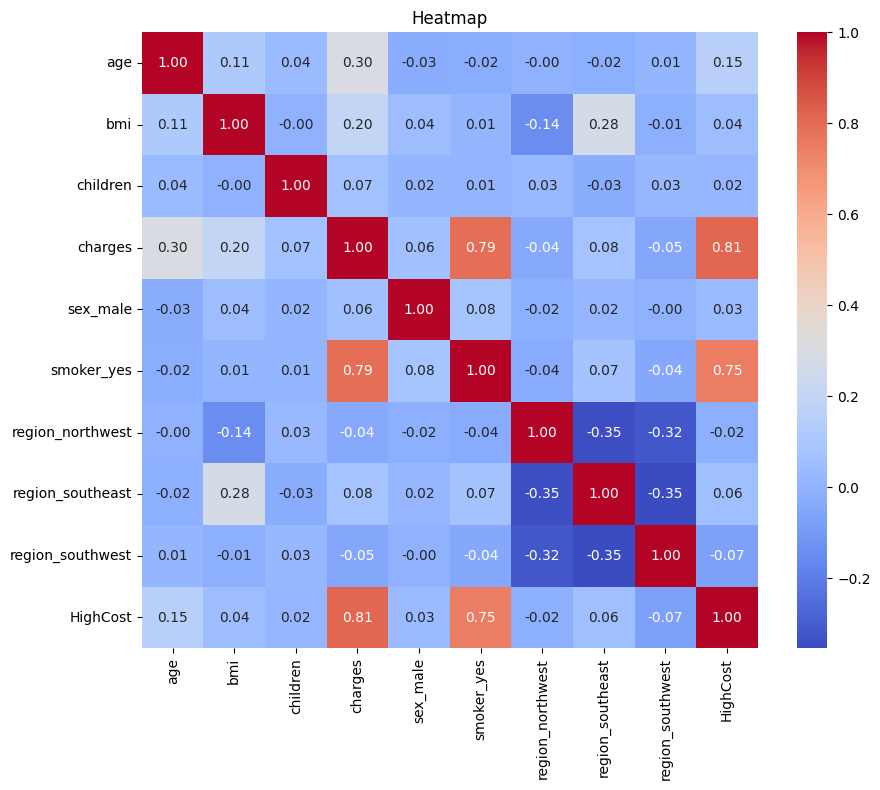

In [ ]:
corr = df_processed.drop(columns='x0').corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Heatmap')
plt.show()


## Logistic Regression for HighCost

In [ ]:
scaler = StandardScaler()
df_encoded = df_processed.drop('charges', axis=1)
X = df_encoded.drop('HighCost', axis=1)
Y = df_encoded['HighCost']

X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

## Evaluation Metrics for Classification

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predict on test set
Y_pred_class = clf.predict(X_test)

# Evaluation Metrics for Classification
accuracy = accuracy_score(Y_test, Y_pred_class)
precision = precision_score(Y_test, Y_pred_class)
recall = recall_score(Y_test, Y_pred_class)
f1 = f1_score(Y_test, Y_pred_class)

print(f"\nLogistic Regression Evaluation (HighCost Classification):")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1 Score : {f1:.4f}")


Logistic Regression Evaluation (HighCost Classification):
  Accuracy : 0.8865
  Precision: 1.0000
  Recall   : 0.6205
  F1 Score : 0.7658


## Confusion Matrix

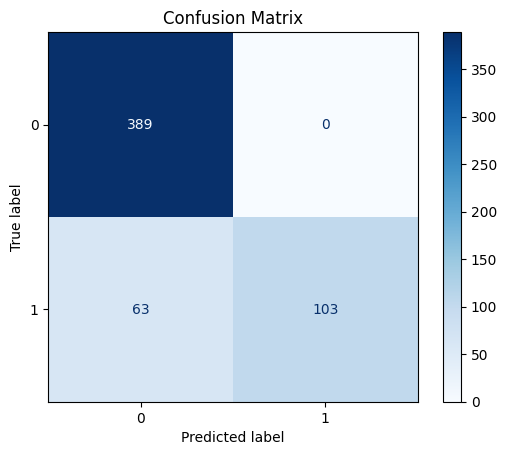

In [ ]:
cm = confusion_matrix(Y_test, Y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

         Feature  Coefficient
      smoker_yes     3.144588
             age     1.033749
        children     0.154476
             bmi     0.075725
              x0     0.000000
region_northwest    -0.048266
region_southeast    -0.118647
        sex_male    -0.154888
region_southwest    -0.275120


<ipython-input-13-971697b73192>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', hue=None, legend=False)


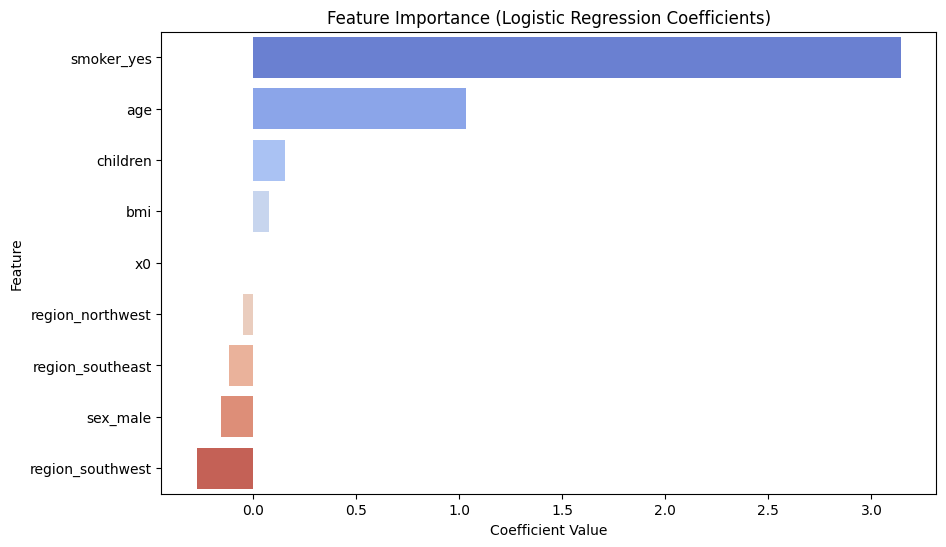

In [ ]:
coefficients = clf.coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.to_string(index=False))

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', hue=None, legend=False)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


## Demo code for new test case

In [ ]:
# Prediction function for a new individual
def predict_randomperson(age, bmi, children, sex, smoker, region):
    data = {
        'age': [age],
        'bmi': [bmi],
        'children': [children],
        'sex_male': [1 if sex == 'male' else 0],
        'smoker_yes': [1 if smoker == 'yes' else 0],
        'region_northwest': [1 if region == 'northwest' else 0],
        'region_northeast': [1 if region == 'northeast' else 0],
        'region_southeast': [1 if region == 'southeast' else 0],
        'region_southwest': [1 if region == 'southwest' else 0],
    }

    df_input = pd.DataFrame(data)

    # Add missing columns from training if necessary
    for col in X.columns:
        if col not in df_input.columns:
            df_input[col] = 0  # assume 0 for missing dummies

    # Ensure column order matches training
    df_input = df_input[X.columns]

    # Scale using the same scaler from training
    input_scaled = scaler.transform(df_input)

    # Predict using logistic regression
    highcost_pred = clf.predict(input_scaled)
    highcost_prob = clf.predict_proba(input_scaled)[0][1]

    # Standardize input for gradient descent prediction
    df_input_std = df_input.copy()
    for col in df_input_std.columns:
        mean = df_processed[col].mean()
        std = df_processed[col].std()
        df_input_std[col] = (df_input_std[col] - mean) / std
    df_input_std['x0'] = 1  # add bias term for theta

    ordered_cols = list(X.columns) + ['x0']
    df_input_std = df_input_std[ordered_cols]

    # Predict charge using theta
    charge_pred = predict_Y(final_theta, df_input_std.values)
    charge_pred = charge_pred * df_processed['charges'].std() + df_processed['charges'].mean()

    print(f"Predicted charge: ${charge_pred[0]:.2f}")
    print(f"HighCost classification: {highcost_pred[0]} (probability: {highcost_prob:.2f})")

predict_randomperson(45, 28.0, 1, 'female', 'no', 'northeast')

Predicted charge: $12719.70
HighCost classification: 0 (probability: 0.19)
